In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better visuals
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Clean column names
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

# Remove obvious outliers in salary
train = train[train['salary'] > 0]

print("Data loaded and initial cleaning done.")
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Data loaded and initial cleaning done.
Train shape: (11157, 13), Test shape: (2790, 12)


# Feature Engineering

In [ ]:
# --- Feature Engineering: Currency Conversion ---
# Exchange rates to USD
rates = {'USD':1.0, 'EUR':1.09, 'GBP':1.27, 'INR':0.012, 'SGD':0.74, 'DKK':0.14,
         'CAD':0.73, 'BRL':0.18, 'CHF':1.13, 'PLN':0.25, 'ILS':0.27, 'TRY':0.03,
         'JPY':0.0065, 'NZD':0.61, 'AUD':0.66, 'THB':0.028, 'HUF':0.0028,
         'ZAR':0.053, 'NOK':0.094, 'HKD':0.128, 'CLP':0.0011, 'MXN':0.058, 'PHP':0.018}

# Map country to currency mode
country_currency_map = train.dropna(subset=['salary_currency']).groupby('Employee Country')['salary_currency'].agg(lambda x:x.mode()[0]).to_dict()

def get_currency_rate(row):
    currency = row['salary_currency']
    country = row['Employee Country']
    if pd.isna(currency):
        currency = country_currency_map.get(country, 'USD')
    return rates.get(currency, 1.0)

train['exchange_rate'] = train.apply(get_currency_rate, axis=1)
test['exchange_rate'] = test.apply(get_currency_rate, axis=1)
train['salary_usd'] = train['salary'] * train['exchange_rate']

# --- Feature Engineering: Job Titles ---
def simplify_job(title):
    if pd.isna(title): return "Other"
    title = title.lower()
    if 'scientist' in title: return 'Data Scientist'
    if 'engineer' in title: return 'Data Engineer'
    if 'analyst' in title: return 'Data Analyst'
    if 'manager' in title or 'head' in title or 'lead' in title or 'director' in title: return 'Manager'
    if 'architect' in title: return 'Architect'
    if 'consultant' in title: return 'Consultant'
    return 'Other'

train['job_group'] = train['Job'].apply(simplify_job)
test['job_group'] = test['Job'].apply(simplify_job)

print("Feature engineering (currency and job grouping) completed.")

Feature engineering (currency and job grouping) completed.


# EDA - Target Variable (Salary in USD)

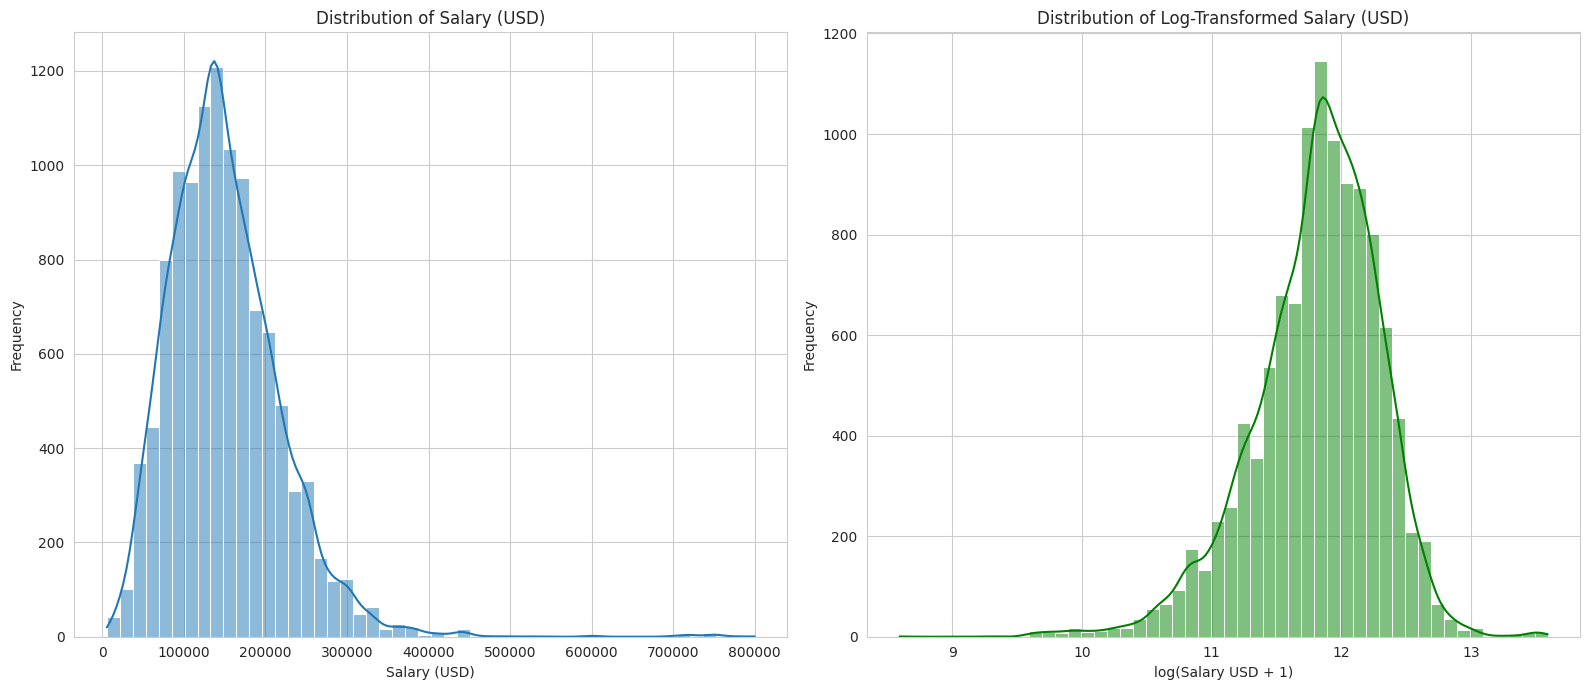

Descriptive statistics for Salary (USD):
count     11157.000000
mean     150224.370174
std       69431.795288
min        5400.000000
25%      102500.000000
50%      141525.000000
75%      186000.000000
max      800000.000000
Name: salary_usd, dtype: float64


In [ ]:
# --- Analysis of the Target Variable (Salary in USD) ---
plt.figure(figsize=(16, 7))

# Plot for the distribution of original salaries in USD
plt.subplot(1, 2, 1)
sns.histplot(train['salary_usd'], kde=True, bins=50)
plt.title('Distribution of Salary (USD)')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')

# Plot for the distribution of log-transformed salaries
plt.subplot(1, 2, 2)
# Create a temporary log_salary column for analysis only
log_salary_usd = np.log1p(train['salary_usd'])
sns.histplot(log_salary_usd, kde=True, bins=50, color='green')
plt.title('Distribution of Log-Transformed Salary (USD)')
plt.xlabel('log(Salary USD + 1)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Descriptive statistics for Salary (USD):")
print(train['salary_usd'].describe())

# EDA - Numerical Features

/tmp/ipython-input-2393563480.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='remote_ratio', data=train, ax=axes[1], palette='viridis')


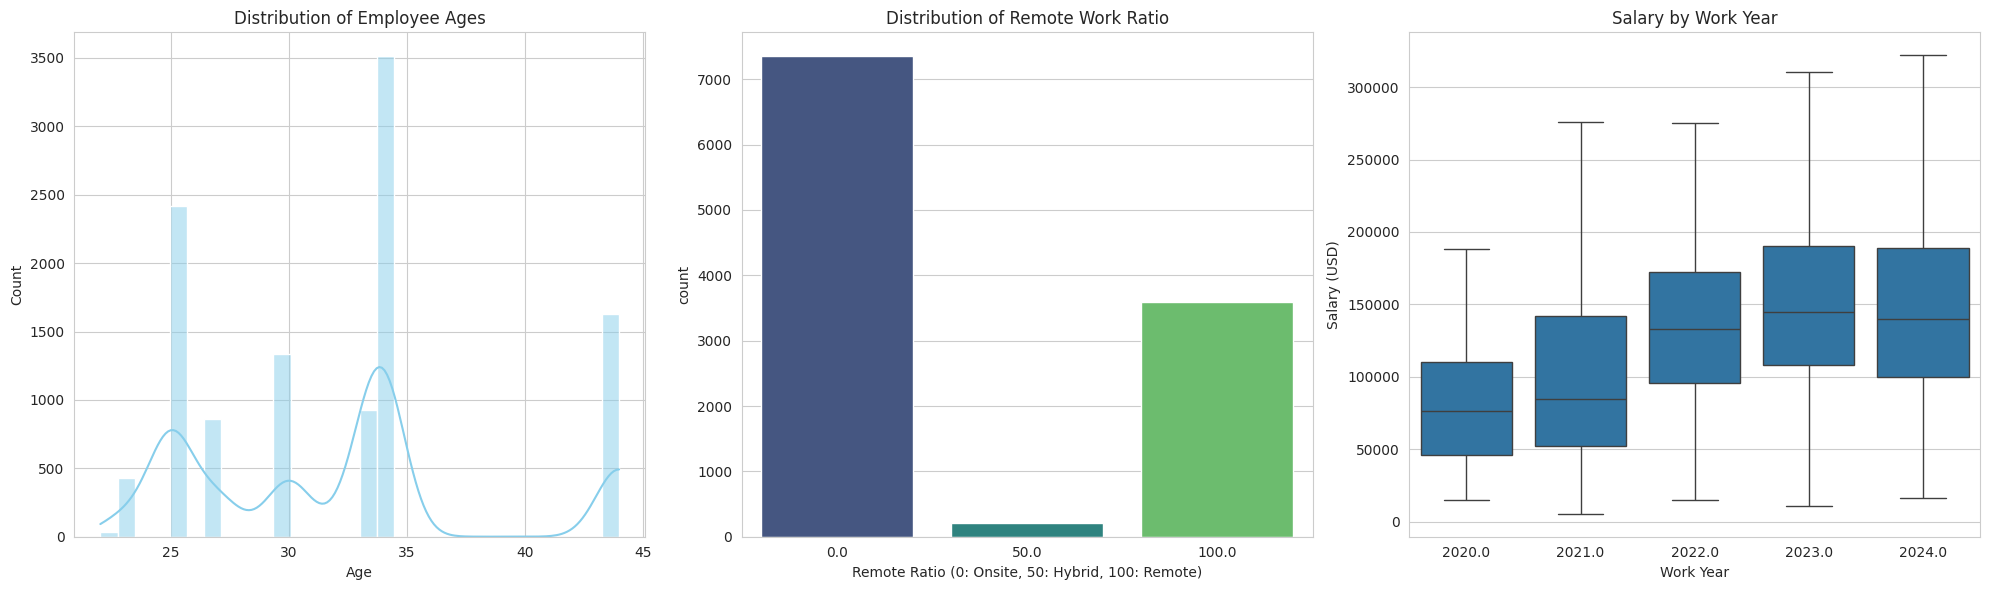

In [ ]:
# --- Analysis of Numerical Features ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Distribution of Age
sns.histplot(train['Age'], kde=True, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Employee Ages')
axes[0].set_xlabel('Age')

# Distribution of Remote Ratio
sns.countplot(x='remote_ratio', data=train, ax=axes[1], palette='viridis')
axes[1].set_title('Distribution of Remote Work Ratio')
axes[1].set_xlabel('Remote Ratio (0: Onsite, 50: Hybrid, 100: Remote)')

# Relationship between Work Year and Salary
sns.boxplot(x='work_year', y='salary_usd', data=train, ax=axes[2], showfliers=False)
axes[2].set_title('Salary by Work Year')
axes[2].set_xlabel('Work Year')
axes[2].set_ylabel('Salary (USD)')

plt.tight_layout()
plt.show()

# EDA - Categorical Features

/tmp/ipython-input-1396423269.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='job_group', data=train, ax=axes[0], palette='rocket', order=train['job_group'].value_counts().index)


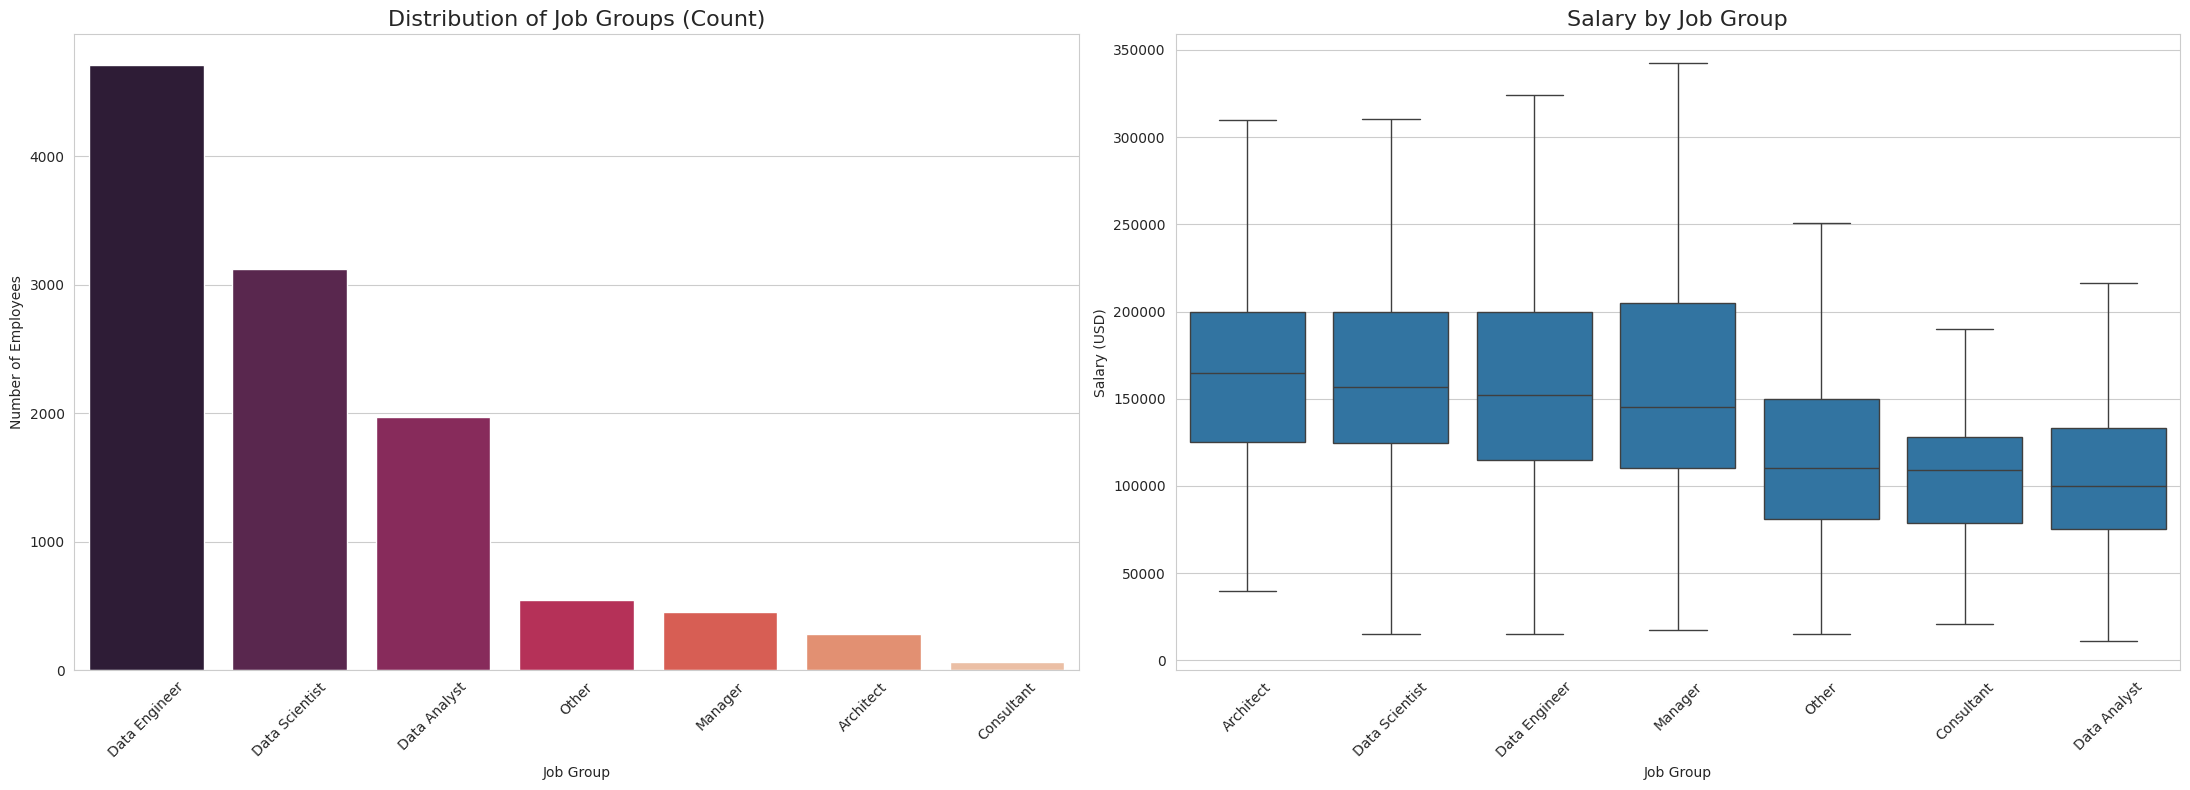

In [ ]:
# --- Analysis of Job Groups ---
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# 1. Distribution of Job Groups (Count)
sns.countplot(x='job_group', data=train, ax=axes[0], palette='rocket', order=train['job_group'].value_counts().index)
axes[0].set_title('Distribution of Job Groups (Count)', fontsize=16)
axes[0].set_xlabel('Job Group')
axes[0].set_ylabel('Number of Employees')
axes[0].tick_params(axis='x', rotation=45)

# 2. Salary by Job Group
sns.boxplot(x='job_group', y='salary_usd', data=train, ax=axes[1], showfliers=False, order=train.groupby('job_group')['salary_usd'].median().sort_values(ascending=False).index)
axes[1].set_title('Salary by Job Group', fontsize=16)
axes[1].set_xlabel('Job Group')
axes[1].set_ylabel('Salary (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

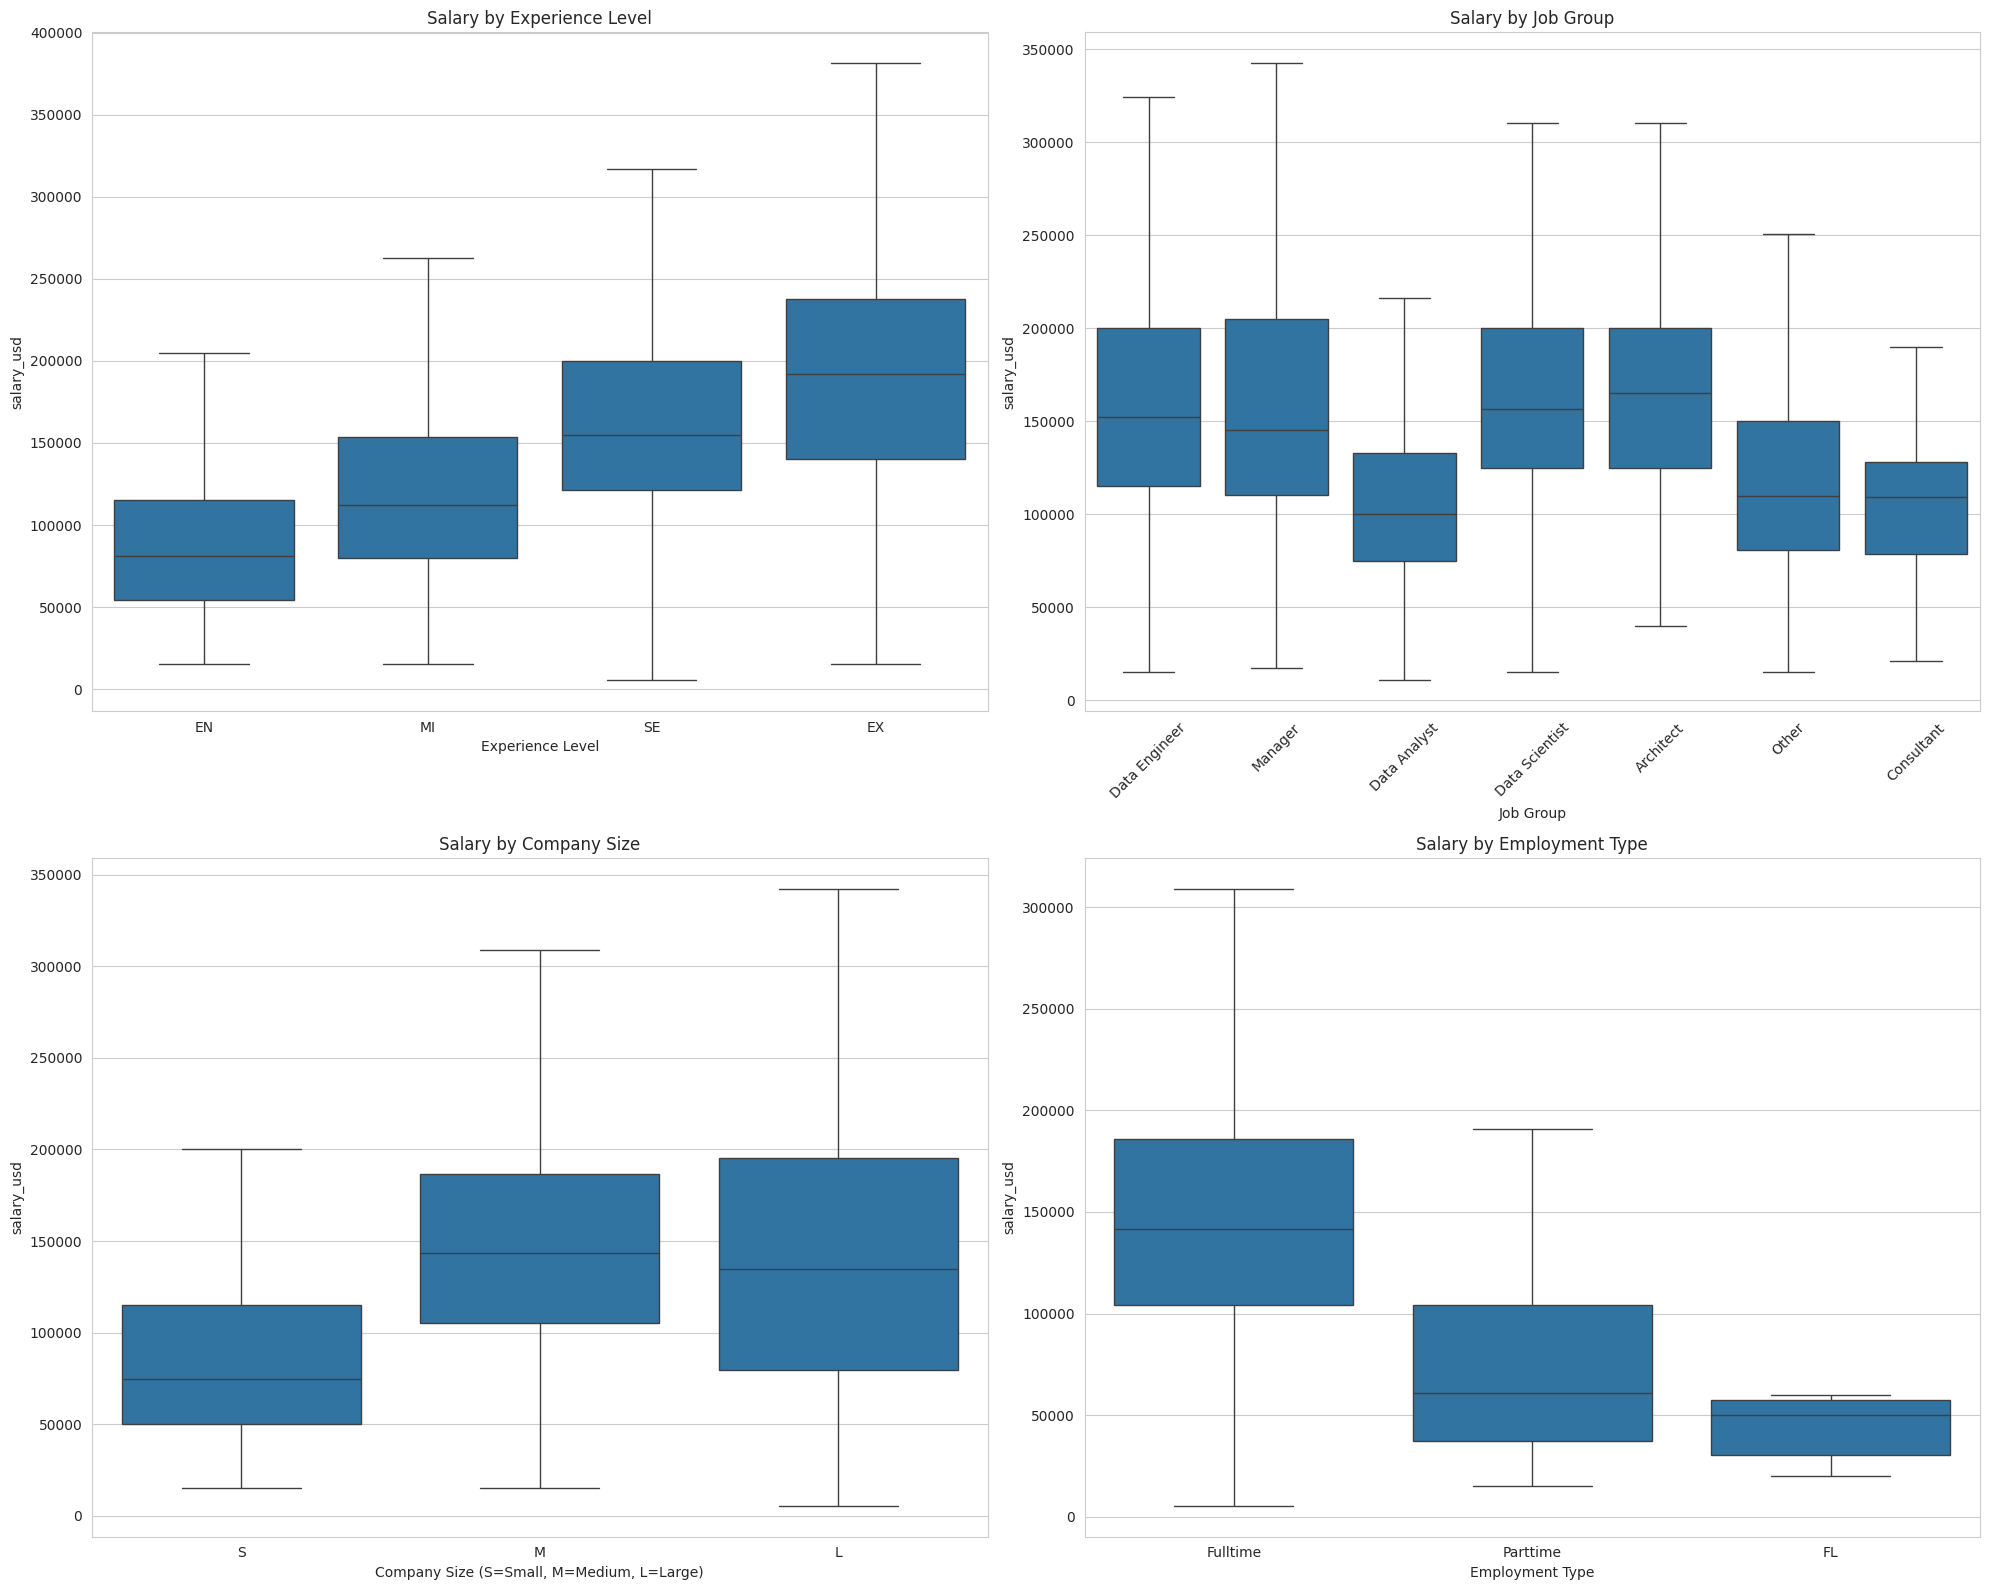

In [ ]:
# --- Analysis of Categorical Features ---
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Salary by Experience Level
sns.boxplot(x='experience_level', y='salary_usd', data=train, ax=axes[0, 0], showfliers=False, order=['EN', 'MI', 'SE', 'EX'])
axes[0, 0].set_title('Salary by Experience Level')
axes[0, 0].set_xlabel('Experience Level')

# Salary by Job Group
sns.boxplot(x='job_group', y='salary_usd', data=train, ax=axes[0, 1], showfliers=False)
axes[0, 1].set_title('Salary by Job Group')
axes[0, 1].set_xlabel('Job Group')
axes[0, 1].tick_params(axis='x', rotation=45)

# Salary by Company Size
sns.boxplot(x='Company Model', y='salary_usd', data=train, ax=axes[1, 0], showfliers=False, order=['S', 'M', 'L'])
axes[1, 0].set_title('Salary by Company Size')
axes[1, 0].set_xlabel('Company Size (S=Small, M=Medium, L=Large)')

# Salary by Employment Type
sns.boxplot(x='employment_type', y='salary_usd', data=train, ax=axes[1, 1], showfliers=False)
axes[1, 1].set_title('Salary by Employment Type')
axes[1, 1].set_xlabel('Employment Type')

plt.tight_layout()
plt.show()

/tmp/ipython-input-1530037883.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='experience_level', data=train, order=order_exp, palette='viridis')
/tmp/ipython-input-1530037883.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='employment_type', data=train, order=train['employment_type'].value_counts().index, palette='plasma')
/tmp/ipython-input-1530037883.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Company Model', data=train, order=order_company, palette='magma')
/tmp/ipython-input-1530037883.py:31: FutureWarnin

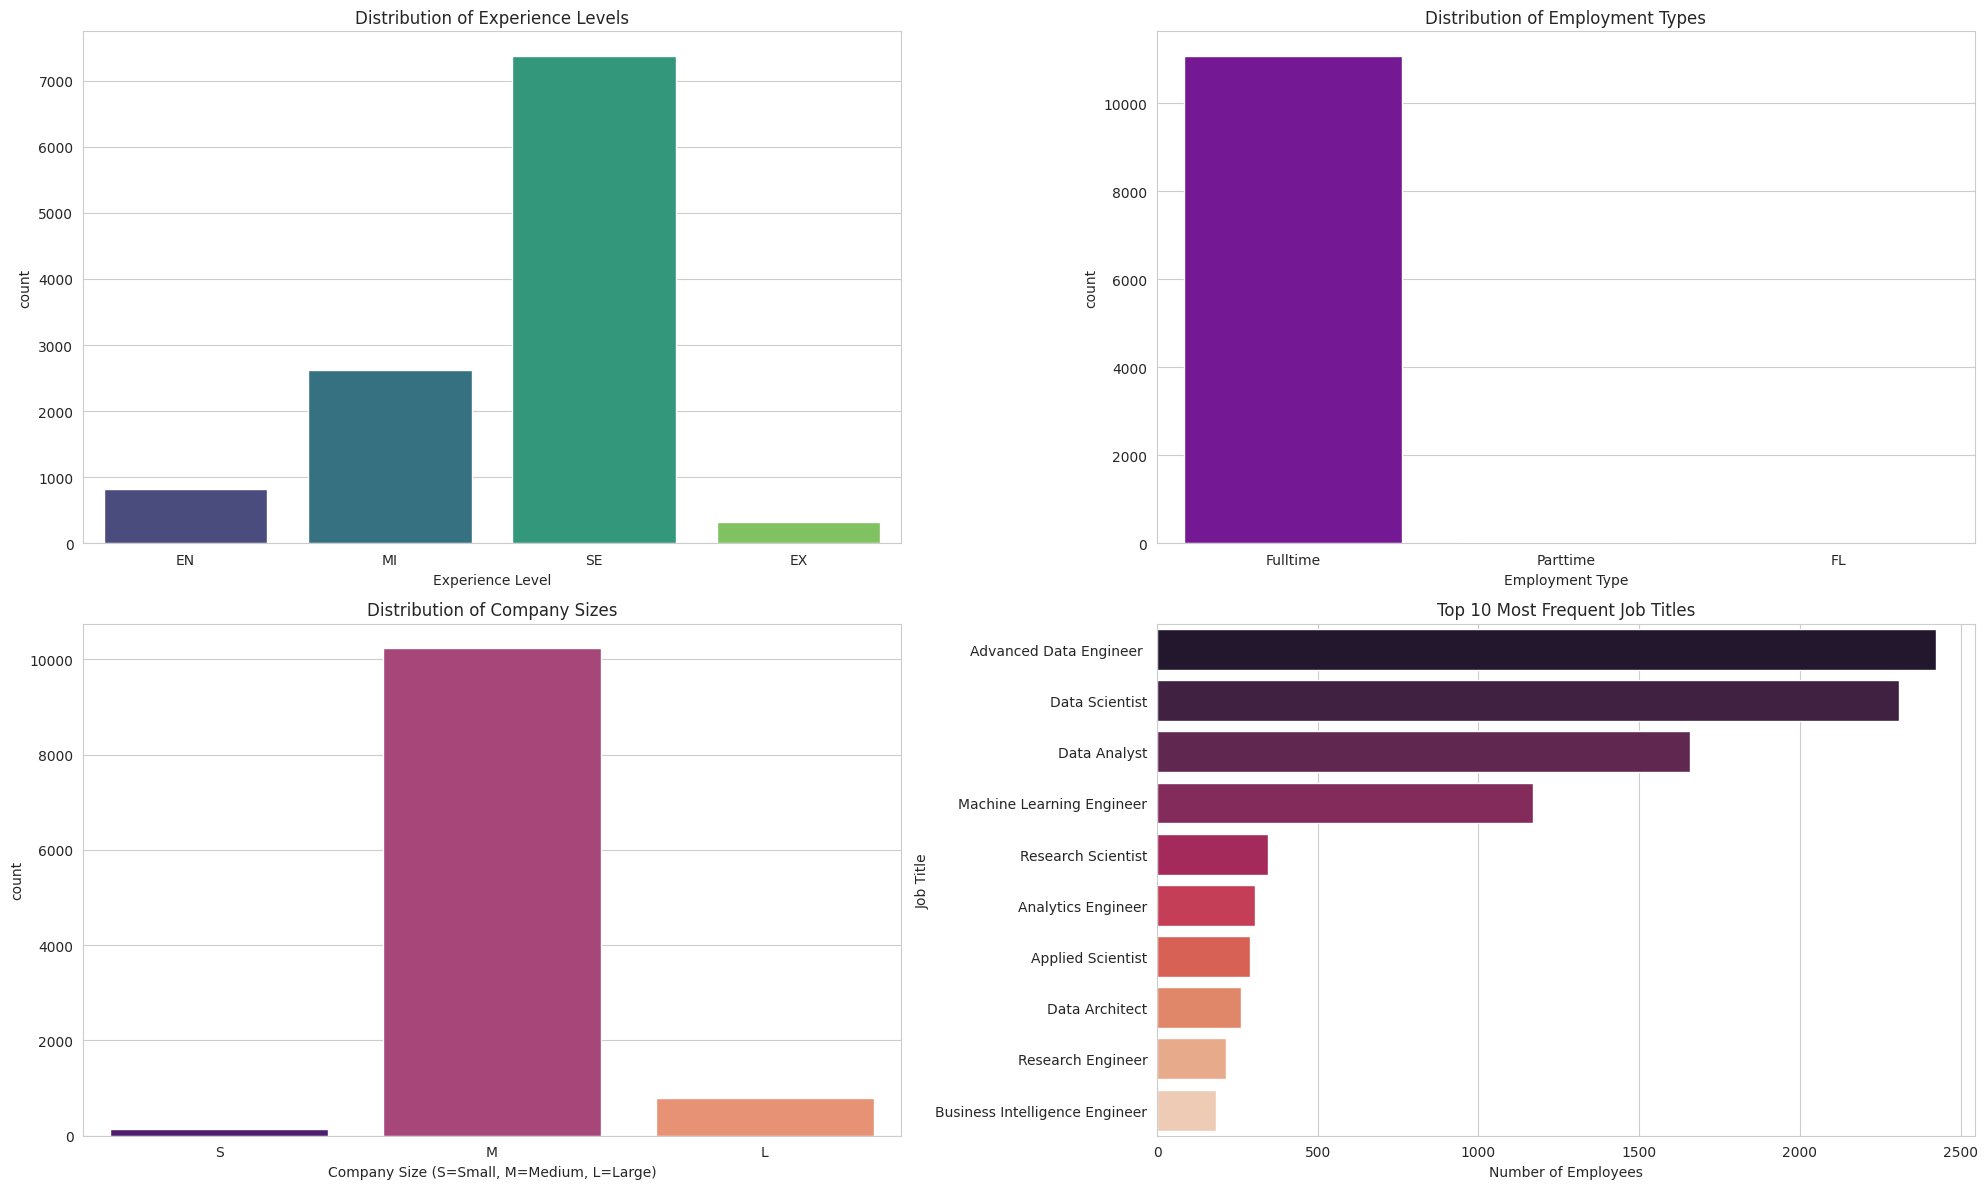

In [ ]:
# --- Analysis of Categorical Feature Distributions and Job Titles ---


plt.figure(figsize=(20, 12))

# Plot 1: Distribution of Experience Levels
plt.subplot(2, 2, 1)
# Order experience levels logically from junior to senior
order_exp = ['EN', 'MI', 'SE', 'EX']
sns.countplot(x='experience_level', data=train, order=order_exp, palette='viridis')
plt.title('Distribution of Experience Levels')
plt.xlabel('Experience Level')

# Plot 2: Distribution of Employment Types
plt.subplot(2, 2, 2)
sns.countplot(x='employment_type', data=train, order=train['employment_type'].value_counts().index, palette='plasma')
plt.title('Distribution of Employment Types')
plt.xlabel('Employment Type')

# Plot 3: Distribution of Company Sizes
plt.subplot(2, 2, 3)
# Order company sizes logically from small to large
order_company = ['S', 'M', 'L']
sns.countplot(x='Company Model', data=train, order=order_company, palette='magma')
plt.title('Distribution of Company Sizes')
plt.xlabel('Company Size (S=Small, M=Medium, L=Large)')

# Plot 4: Top 10 Most Frequent Job Titles (Original Titles)
plt.subplot(2, 2, 4)
top_10_jobs = train['Job'].value_counts().nlargest(10)
sns.barplot(y=top_10_jobs.index, x=top_10_jobs.values, orient='h', palette='rocket')
plt.title('Top 10 Most Frequent Job Titles')
plt.xlabel('Number of Employees')
plt.ylabel('Job Title')

plt.tight_layout()
plt.show()

# EDA - Correlation Matrix

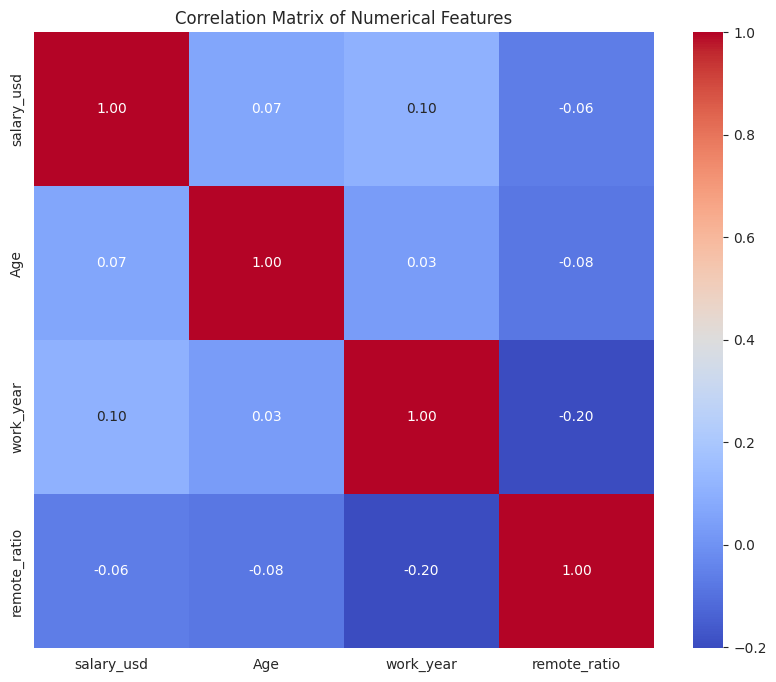

In [ ]:
# --- Correlation Matrix of Numerical Variables ---
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_cols = ['salary_usd', 'Age', 'work_year', 'remote_ratio']
correlation_matrix = train[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Preprocessing

In [ ]:
# Fill numeric nulls
num_cols = ['work_year','Age','remote_ratio']
for col in num_cols:
    med = train[col].median()
    train[col] = train[col].fillna(med)
    test[col] = test[col].fillna(med)

# Fill categorical nulls
cat_cols = ['experience_level','employment_type','job_group','Employee Country','Working Model','Country','Company Model']
for col in cat_cols:
    mode = train[col].mode()[0]
    train[col] = train[col].fillna(mode)
    test[col] = test[col].fillna(mode)

# Encode categorical
from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    le = LabelEncoder()
    full_data = pd.concat([train[col], test[col]]).astype(str)
    le.fit(full_data)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

print("Missing values handled and categorical features encoded.")

Missing values handled and categorical features encoded.


# Model Training and Evaluation

In [ ]:
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

# Features & target
X = train[num_cols + cat_cols]
y = np.log1p(train['salary_usd']) # Using log-transformed salary as target
X_test = test[num_cols + cat_cols]

# Standard scaling (important for SVM and Neural Network)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Linear Regression ---
lr = LinearRegression()
scores = -cross_val_score(lr, X_scaled, y, cv=kf, scoring='neg_root_mean_squared_error')
print("Linear Regression CV RMSE:", scores.mean())

# --- Random Forest ---
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_params = {'n_estimators':[200,300],'max_depth':[10,15]}
rf_search = RandomizedSearchCV(rf_model, rf_params, n_iter=4, scoring='neg_root_mean_squared_error', cv=kf, random_state=42)
rf_search.fit(X_scaled, y)
best_rf = rf_search.best_estimator_

scores = -cross_val_score(best_rf, X_scaled, y, cv=kf, scoring='neg_root_mean_squared_error')
print("Random Forest CV RMSE:", scores.mean())

# --- Support Vector Regressor (SVM) ---
svm_model = SVR(kernel='rbf')
svm_params = {'C':[1,10], 'gamma':['scale','auto']}
svm_search = RandomizedSearchCV(svm_model, svm_params, n_iter=4, scoring='neg_root_mean_squared_error', cv=kf, random_state=42)
svm_search.fit(X_scaled, y)
best_svm = svm_search.best_estimator_

scores = -cross_val_score(best_svm, X_scaled, y, cv=kf, scoring='neg_root_mean_squared_error')
print("SVM CV RMSE:", scores.mean())

# --- Neural Network ---
nn_model = MLPRegressor(max_iter=500, random_state=42)
nn_params = {'hidden_layer_sizes':[(100,50),(150,75)], 'learning_rate_init':[0.001,0.01]}
nn_search = RandomizedSearchCV(nn_model, nn_params, n_iter=4, scoring='neg_root_mean_squared_error', cv=kf, random_state=42)
nn_search.fit(X_scaled, y)
best_nn = nn_search.best_estimator_

scores = -cross_val_score(best_nn, X_scaled, y, cv=kf, scoring='neg_root_mean_squared_error')
print("Neural Network CV RMSE:", scores.mean())

Linear Regression CV RMSE: 0.4268670667811234
Random Forest CV RMSE: 0.36804028596121163
SVM CV RMSE: 0.38937223886403716
Neural Network CV RMSE: 0.4028058502039012


# Ensemble and Prediction

In [ ]:
from sklearn.ensemble import VotingRegressor
import pandas as pd
import numpy as np

ensemble = VotingRegressor(estimators=[
    ('lr', lr),        # Linear Regression
    ('rf', best_rf),   # Random Forest
    ('svm', best_svm), # SVM
    ('nn', best_nn)    # Neural Network
])

ensemble.fit(X_scaled, y)

# CV RMSE for Ensemble
scores = -cross_val_score(ensemble, X_scaled, y, cv=kf, scoring='neg_root_mean_squared_error')
print("Ensemble CV RMSE:", scores.mean())

# Predict on test set
pred_log_usd = ensemble.predict(X_test_scaled)
pred_usd = np.expm1(pred_log_usd)
final_pred_raw = pred_usd

submission = pd.DataFrame({'id': test['id'], 'Monthly_Salary': final_pred_raw})
submission.to_csv('submission.csv', index=False)

print("\nSubmission file 'submission.csv' created successfully.")
print(submission.head())

Ensemble CV RMSE: 0.38077249362234

Submission file 'submission.csv' created successfully.
      id  Monthly_Salary
0   9867   161988.139585
1    366   112451.977001
2  11283   186853.598653
3  13922    58577.241201
4    148   168150.825600


/tmp/ipython-input-3172525828.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='RMSE', y='Model', data=rmse_df, palette='viridis')


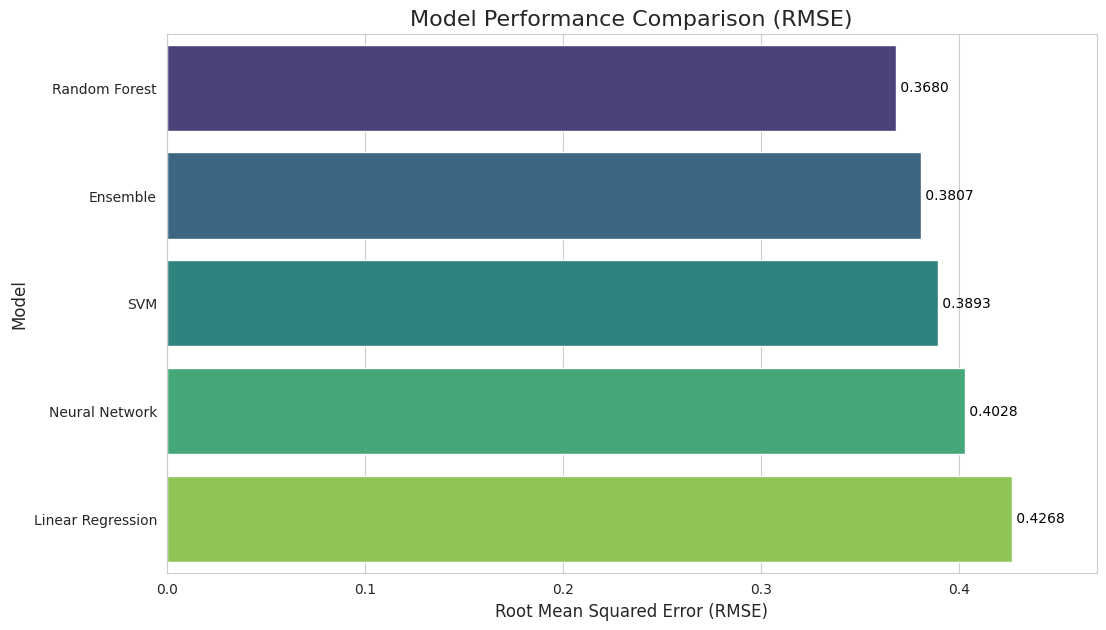

In [ ]:
# --- Model Performance Comparison (RMSE) ---
model_rmse = {
    "Linear Regression": 0.4268,
    "Random Forest": 0.3680,
    "SVM": 0.3893,
    "Neural Network": 0.4028,
    "Ensemble": 0.3807
}

rmse_df = pd.DataFrame(list(model_rmse.items()), columns=['Model', 'RMSE'])


rmse_df = rmse_df.sort_values(by='RMSE', ascending=True)


plt.figure(figsize=(12, 7))
barplot = sns.barplot(x='RMSE', y='Model', data=rmse_df, palette='viridis')

for index, value in enumerate(rmse_df['RMSE']):
    barplot.text(value, index, f' {value:.4f}', color='black', ha="left", va="center")

plt.title('Model Performance Comparison (RMSE)', fontsize=16)
plt.xlabel('Root Mean Squared Error (RMSE)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, rmse_df['RMSE'].max() * 1.1)
plt.show()
